In [22]:
# from google.colab import drive
# drive.mount('/content/drive')

In [23]:
train_dir = "/content/drive/MyDrive/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/FruitinAmazon/test"

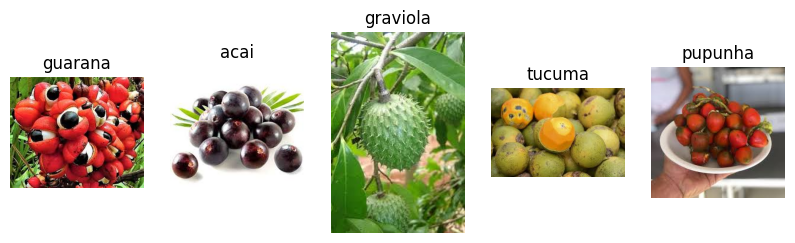

In [24]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


def display_sample_images(directory, num_images=5):
    classes = os.listdir(directory)
    plt.figure(figsize=(10, 5))

    for i, class_name in enumerate(classes[:num_images]):
        class_dir = os.path.join(directory, class_name)
        image_name = random.choice(os.listdir(class_dir))
        img_path = os.path.join(class_dir, image_name)
        img = Image.open(img_path)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.show()
display_sample_images(train_dir)

What did you Observe?

Answer:- one random image of each category is diplayed

In [33]:
class_dirs = os.listdir(train_dir)

corrupted_images = []

for class_dir in class_dirs:
    class_path = os.path.join(train_dir, class_dir)

    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            try:
                Image.open(image_path)
            except (IOError, SyntaxError):
                os.remove(image_path)
                corrupted_images.append(image_path)
                print(f"Removed corrupted image: {image_path}")

if not corrupted_images:
    print("No corrupted images found.")


No corrupted images found.


In [26]:
# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255)

# Load training data
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Normalize training data
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Load validation data
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Normalize validation data
val_ds = val_ds.map(lambda x, y: (rescale(x), y))


Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [27]:

# Define the CNN architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(len(class_dirs), activation='softmax')
])

# Display model summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │       2,097,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [29]:
# Define callbacks
callbacks = [
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(patience=4, restore_best_weights=True)
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=callbacks
)


Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step - accuracy: 0.1250 - loss: 1.8959

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 615ms/step - accuracy: 0.1250 - loss: 1.9085 - val_accuracy: 0.3333 - val_loss: 1.6822
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 527ms/step - accuracy: 0.3385 - loss: 1.8560 - val_accuracy: 0.1667 - val_loss: 1.7959
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.2079 - loss: 1.6410 - val_accuracy: 0.2222 - val_loss: 1.8081
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.2986 - loss: 1.5121

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 908ms/step - accuracy: 0.3073 - loss: 1.5024 - val_accuracy: 0.7222 - val_loss: 1.3550
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.5191 - loss: 1.2721

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 494ms/step - accuracy: 0.5247 - loss: 1.2698 - val_accuracy: 0.7778 - val_loss: 1.0225
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.5286 - loss: 1.0912 - val_accuracy: 0.6111 - val_loss: 1.2194
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7292 - loss: 0.8205

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 500ms/step - accuracy: 0.7344 - loss: 0.8155 - val_accuracy: 0.7778 - val_loss: 0.9329
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.7992 - loss: 0.6615

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 506ms/step - accuracy: 0.8043 - loss: 0.6589 - val_accuracy: 0.8333 - val_loss: 0.5329
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 791ms/step - accuracy: 0.9566 - loss: 0.3152 - val_accuracy: 0.8333 - val_loss: 0.8040
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 752ms/step - accuracy: 0.9627 - loss: 0.2334 - val_accuracy: 0.7222 - val_loss: 0.7232
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9699 - loss: 0.1246

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 577ms/step - accuracy: 0.9705 - loss: 0.1212 - val_accuracy: 0.9444 - val_loss: 0.3801
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 517ms/step - accuracy: 1.0000 - loss: 0.0806 - val_accuracy: 0.8333 - val_loss: 0.8208
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step - accuracy: 1.0000 - loss: 0.0461 - val_accuracy: 0.8333 - val_loss: 0.5239
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 1.0000 - loss: 0.0116

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 700ms/step - accuracy: 1.0000 - loss: 0.0121 - val_accuracy: 0.8889 - val_loss: 0.2415
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 1.0000 - loss: 0.0104

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 676ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 0.8889 - val_loss: 0.2170
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 793ms/step - accuracy: 1.0000 - loss: 0.0055 - val_accuracy: 0.8889 - val_loss: 0.3213
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 532ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.8889 - val_loss: 0.3451
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 464ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.8333 - val_loss: 0.3691
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 452ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.8333 - val_loss: 0.4208


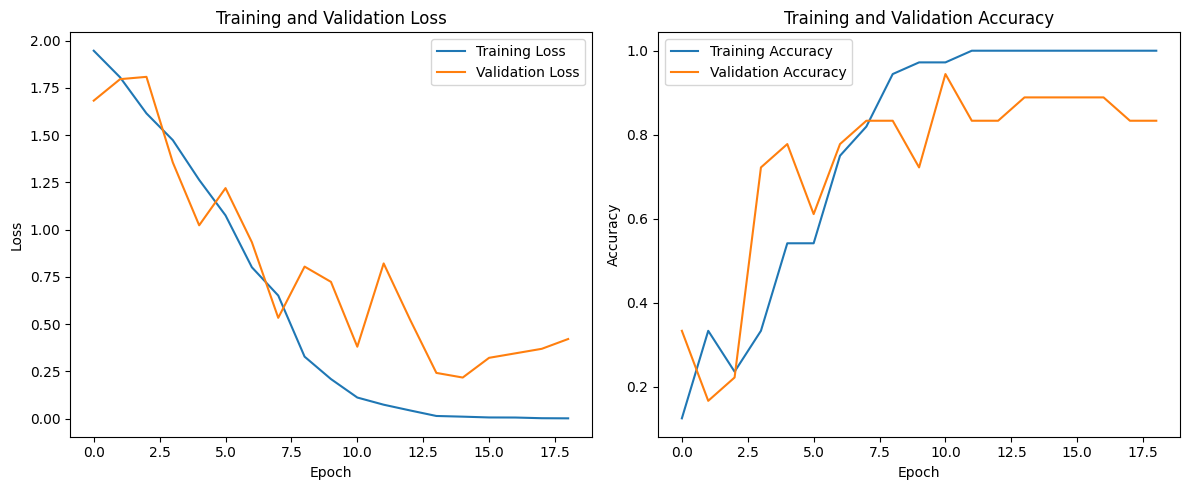

In [35]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


In [30]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_loss, test_acc = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc}, Test loss: {test_loss}')


Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.6667 - loss: 229.0742
Test accuracy: 0.6666666865348816, Test loss: 229.07424926757812


In [31]:
# Save the model
model_save_path = "/content/drive/My Drive/Week5FinalModel.h5"

model.save(model_save_path)

# Load the saved model
loaded_model = tf.keras.models.load_model(model_save_path)

# Re-evaluate on test data
test_loss, test_acc = loaded_model.evaluate(test_ds)
print(f'Test accuracy after loading: {test_acc}, Test loss: {test_loss}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 849ms/step - accuracy: 0.6667 - loss: 229.0742
Test accuracy after loading: 0.6666666865348816, Test loss: 229.07424926757812


In [32]:
# Predict on test data
predictions = loaded_model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

# Get true labels
true_labels = np.concatenate([y for _, y in test_ds], axis=0)

# Classification report
print(classification_report(true_labels, predicted_labels))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step
              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.40      0.80      0.53         5
           2       0.80      0.80      0.80         5
           3       0.75      0.60      0.67         5
           4       0.80      0.80      0.80         5
           5       1.00      0.40      0.57         5

    accuracy                           0.67        30
   macro avg       0.75      0.67      0.67        30
weighted avg       0.75      0.67      0.67        30

